**Covers:**
- Layer 1: Business Analytics (EDA, SQL, Visualizations)
- Layer 2: Feature Engineering + Statistical Validation
- Layer 3: AI/ML Pipeline (XGBoost, SMOTE, Threshold Tuning, Model Deployment)

**Dataset:** [Transactions Fraud Dataset — Kaggle](https://www.kaggle.com/datasets/computingvictor/transactions-fraud-datasets)

---
##Setup: Install Dependencies

In [3]:
# Install all required packages at once
!pip install kagglehub geopy imbalanced-learn xgboost pandasql joblib scikit-learn --quiet

---
##Step 1: Load Data

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')



# Download dataset 
path = kagglehub.dataset_download("computingvictor/transactions-fraud-datasets")
print("Dataset path:", path)


# Load transactions ─────────────────
csv_path = os.path.join(path, 'transactions_data.csv')
df = pd.read_csv(csv_path)
print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns")



#Load & merge fraud labels ──────────────
labels_path = os.path.join(path, 'train_fraud_labels.json')
with open(labels_path, 'r') as f:
    labels_data = json.load(f)

labels_dict = labels_data.get('target', {})
df['is_fraud'] = (
    df['id'].astype(str)
      .map(labels_dict)
      .map({'Yes': 1, 'No': 0})
      .fillna(0)
      .astype(int)
)



#Clean amount column ────────────────
if df['amount'].dtype == object:
    df['amt'] = df['amount'].str.replace(r'[$,]', '', regex=True).astype(float)
else:
    df['amt'] = df['amount'].astype(float)

print(f"\n Fraud Distribution:")
print(df['is_fraud'].value_counts().rename({0:'Legit', 1:'Fraud'}).to_string())
print(f"\nFraud Rate: {df['is_fraud'].mean()*100:.2f}%")
df.head(3)

Using Colab cache for faster access to the 'transactions-fraud-datasets' dataset.
📂 Dataset path: /kaggle/input/transactions-fraud-datasets
✅ Loaded 13,305,915 rows × 12 columns

📊 Fraud Distribution:
is_fraud
Legit    13292583
Fraud       13332

Fraud Rate: 0.10%


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,is_fraud,amt
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN,0,-77.00
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN,0,14.57
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN,0,80.00


To manage memory with the large dataset, we will downsample it for subsequent analysis. You can adjust the `sample_size` as needed.

In [ ]:
# Downsample the DataFrame to reduce memory usage
# Adjust sample_size as needed for your available RAM
sample_size = 100000
if len(df) > sample_size:
    df = df.sample(n=sample_size, random_state=42).reset_index(drop=True)
    print(f"Downsampled DataFrame to {df.shape[0]:,} rows.")
else:
    print("DataFrame size is already manageable.")

    

# Display basic info of the downsampled DataFrame
print("\nDownsampled DataFrame Info:")
df.info()

📉 Downsampled DataFrame to 100,000 rows.

Downsampled DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              100000 non-null  int64  
 1   date            100000 non-null  object 
 2   client_id       100000 non-null  int64  
 3   card_id         100000 non-null  int64  
 4   amount          100000 non-null  object 
 5   use_chip        100000 non-null  object 
 6   merchant_id     100000 non-null  int64  
 7   merchant_city   100000 non-null  object 
 8   merchant_state  88259 non-null   object 
 9   zip             87574 non-null   float64
 10  mcc             100000 non-null  int64  
 11  errors          1543 non-null    object 
 12  is_fraud        100000 non-null  int64  
 13  amt             100000 non-null  float64
dtypes: float64(2), int64(6), object(6)
memory usage: 10.7+ MB


---
## Layer 1 Business Analytics
### 1.1 Data Quality Check

In [ ]:
print("=" * 55)
print("       DATA QUALITY REPORT")
print("=" * 55)
print(f"Shape          : {df.shape}")
print(f"Duplicate Rows : {df.duplicated().sum()}")
print(f"\nMissing Values:")
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing if not missing.empty else "  None found")
print(f"\nData Types:")
print(df.dtypes.value_counts())
print("\nNumerical Summary:")
df.describe(include='number').round(2)

       DATA QUALITY REPORT
Shape          : (100000, 14)
Duplicate Rows : 0

Missing Values:
merchant_state    11741
zip               12426
errors            98457
dtype: int64

Data Types:
int64      6
object     6
float64    2
Name: count, dtype: int64

Numerical Summary:


,id,client_id,card_id,merchant_id,zip,mcc,is_fraud,amt
count,100000.00,100000.00,100000.00,100000.00,87574.00,100000.00,100000.00,100000.00
mean,15566985.69,1025.97,3474.06,47774.70,51293.31,5562.03,0.00,42.92
std,4704250.91,582.57,1674.35,25859.88,29376.95,868.09,0.03,81.04
min,7475640.00,0.00,0.00,5.00,1040.00,1711.00,0.00,-498.00
25%,11475332.75,515.00,2416.00,25887.00,28586.00,5300.00,0.00,8.88
50%,15554795.50,1073.00,3583.00,45968.00,47542.00,5499.00,0.00,29.00
75%,19641608.75,1530.00,4893.00,68147.00,77857.00,5812.00,0.00,63.56
max,23761565.00,1998.00,6138.00,100340.00,99707.00,9402.00,1.00,2554.70


### 1.2 Fraud Overview Dashboard

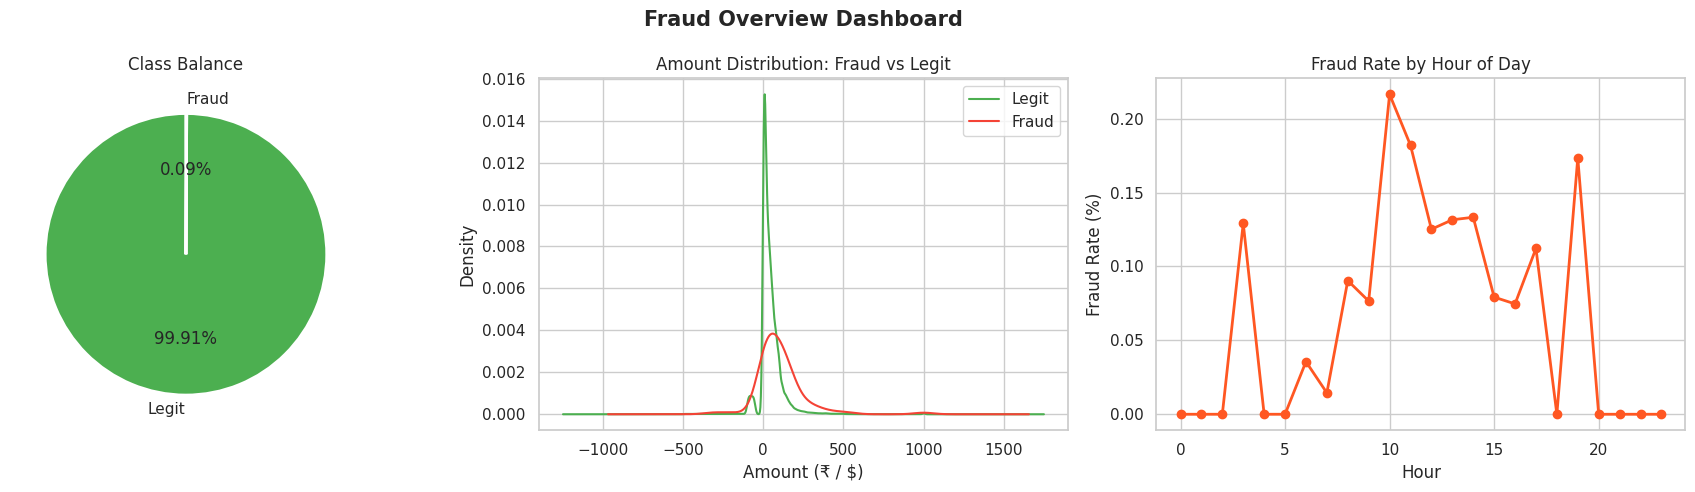

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fraud Overview Dashboard', fontsize=15, fontweight='bold')

#Class distribution ────────────────────
counts = df['is_fraud'].value_counts().rename({0: 'Legit', 1: 'Fraud'})
axes[0].pie(counts, labels=counts.index, autopct='%1.2f%%',
            colors=['#4CAF50', '#F44336'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Class Balance')



#Transaction amount distribution ───────────────
axes[1].set_title('Amount Distribution: Fraud vs Legit')
df[df.is_fraud == 0]['amt'].clip(upper=1000).plot.kde(ax=axes[1], label='Legit', color='#4CAF50')
df[df.is_fraud == 1]['amt'].clip(upper=1000).plot.kde(ax=axes[1], label='Fraud', color='#F44336')
axes[1].set_xlabel('Amount (₹ / $)')
axes[1].legend()


#Fraud by hour (if datetime available) ─────────────────
if 'date' in df.columns:
    df['trans_dt'] = pd.to_datetime(df['date'], errors='coerce')
    df['hour'] = df['trans_dt'].dt.hour
    hourly_fraud = df.groupby('hour')['is_fraud'].mean() * 100
    hourly_fraud.plot(kind='line', ax=axes[2], color='#FF5722', marker='o', linewidth=2)
    axes[2].set_title('Fraud Rate by Hour of Day')
    axes[2].set_xlabel('Hour')
    axes[2].set_ylabel('Fraud Rate (%)')
else:
    axes[2].text(0.5, 0.5, 'No datetime column found', ha='center', va='center', transform=axes[2].transAxes)

plt.tight_layout()
plt.show()

### 1.3 Geographic & Merchant Risk Analysis

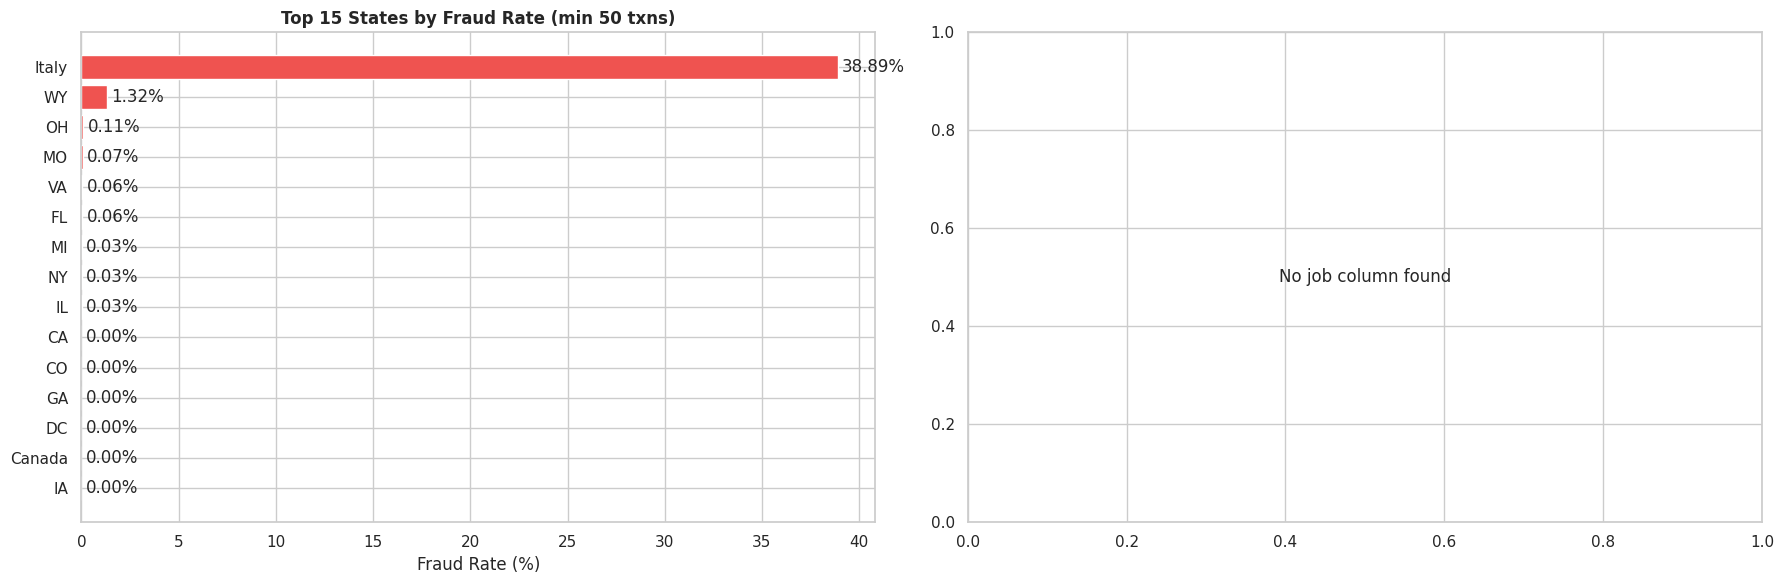

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#State-level fraud rate ────────────────────────
state_col = 'merchant_state' if 'merchant_state' in df.columns else ('state' if 'state' in df.columns else None)
if state_col:
    state_fraud = (
        df.groupby(state_col)['is_fraud']
          .agg(fraud_rate='mean', txn_count='count')
          .query('txn_count > 50')
          .sort_values('fraud_rate', ascending=False)
          .head(15)
    )
    bars = axes[0].barh(state_fraud.index, state_fraud['fraud_rate'] * 100, color='#EF5350')
    axes[0].bar_label(bars, fmt='%.2f%%', padding=3)
    axes[0].set_title('Top 15 States by Fraud Rate (min 50 txns)', fontweight='bold')
    axes[0].set_xlabel('Fraud Rate (%)')
    axes[0].invert_yaxis()
else:
    axes[0].text(0.5, 0.5, 'No state column found', ha='center', va='center', transform=axes[0].transAxes)


#Fraud by job / occupation ─────────────────
if 'job' in df.columns:
    job_fraud = (
        df.groupby('job')['is_fraud']
          .agg(fraud_rate='mean', txn_count='count')
          .query('txn_count > 100')
          .sort_values('fraud_rate', ascending=False)
          .head(10)
    )
    bars2 = axes[1].barh(job_fraud.index, job_fraud['fraud_rate'] * 100, color='#42A5F5')
    axes[1].bar_label(bars2, fmt='%.2f%%', padding=3)
    axes[1].set_title('Top 10 High-Risk Occupations (min 100 txns)', fontweight='bold')
    axes[1].set_xlabel('Fraud Rate (%)')
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, 'No job column found', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

### 1.4 SQL-Based Business Intelligence (pandasql)

In [ ]:
from pandasql import sqldf

pysql = lambda q: sqldf(q, {'df': df})

#Q1: Top 10 merchants by fraud volume ────────────────────────
merchant_col = 'merchant_id' if 'merchant_id' in df.columns else 'merchant'
if merchant_col in df.columns:
    q1 = f"""
    SELECT
        {merchant_col}                             AS merchant,
        COUNT(*)                                    AS total_txns,
        SUM(is_fraud)                              AS fraud_count,
        ROUND(AVG(is_fraud) * 100, 2)              AS fraud_rate_pct,
        ROUND(AVG(amt), 2)                         AS avg_txn_amt
    FROM df
    GROUP BY {merchant_col}
    HAVING total_txns > 5
    ORDER BY fraud_count DESC
    LIMIT 10;
    """
    print("Q1: Top 10 Merchants by Fraud Volume")
    display(pysql(q1))
else:
    print(f"Column '{merchant_col}' not found — skipping Q1")



#Q2: High-value fraud transactions (potential card-not-present attacks)
city_col  = 'merchant_city'  if 'merchant_city'  in df.columns else 'city'
state_col2= 'merchant_state' if 'merchant_state' in df.columns else 'state'

# Build query dynamically based on available columns
select_cols = 'client_id, amt, is_fraud'
if city_col  in df.columns: select_cols += f', {city_col}'
if state_col2 in df.columns: select_cols += f', {state_col2}'

q2 = f"""
SELECT {select_cols}
FROM df
WHERE is_fraud = 1 AND amt > 500
ORDER BY amt DESC
LIMIT 10;
"""
print("\nQ2: High-Value Fraud Transactions (>500)")
display(pysql(q2))

#Q3: Fraud rate by state ─────────────────────────────
if state_col2 in df.columns:
    q3 = f"""
    SELECT
        {state_col2}                               AS state,
        COUNT(*)                                    AS total_txns,
        ROUND(AVG(is_fraud) * 100, 2)              AS fraud_rate_pct
    FROM df
    GROUP BY {state_col2}
    HAVING total_txns > 20
    ORDER BY fraud_rate_pct DESC
    LIMIT 10;
    """
    print("\nQ3: Top 10 States by Fraud Rate (min 20 txns)")
    display(pysql(q3))

📋 Q1: Top 10 Merchants by Fraud Volume


,merchant,total_txns,fraud_count,fraud_rate_pct,avg_txn_amt
0,60569,2354,6,0.25,65.93
1,27092,4429,5,0.11,90.05
2,99370,248,3,1.21,62.76
3,59474,99,3,3.03,51.83
4,34490,306,3,0.98,49.92
5,76639,41,2,4.88,141.46
6,75034,13,2,15.38,159.65
7,71883,72,2,2.78,57.87
8,67570,253,2,0.79,62.72
9,61738,25,2,8.00,44.49



📋 Q2: High-Value Fraud Transactions (>500)


,client_id,amt,is_fraud,merchant_city,merchant_state
0,637,2065.14,1,ONLINE,None
1,1173,525.07,1,Glenrock,WY



📋 Q3: Top 10 States by Fraud Rate (min 20 txns)


,state,total_txns,fraud_rate_pct
0,Italy,54,38.89
1,WY,76,1.32
2,None,11741,0.44
3,OH,3715,0.11
4,MO,1485,0.07
5,VA,1691,0.06
6,FL,5272,0.06
7,NY,6625,0.03
8,MI,3031,0.03
9,IL,3487,0.03


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


##Layer 2 — Feature Engineering
### 2.1 Geospatial Feature: Distance to Merchant

In [ ]:
from geopy.distance import geodesic

geo_cols = ['lat', 'long', 'merch_lat', 'merch_long']
if all(c in df.columns for c in geo_cols):
    print("Calculating geodesic distance (user ↔ merchant)...")
    # Vectorized via numpy for speed

    
    def fast_distance(lat1, lon1, lat2, lon2):
        try:
            return geodesic((lat1, lon1), (lat2, lon2)).km
        except Exception:
            return np.nan

    df['dist_to_merch'] = [
        fast_distance(r['lat'], r['long'], r['merch_lat'], r['merch_long'])
        for _, r in df[geo_cols].iterrows()
    ]
    print(f"'dist_to_merch' created. Mean={df['dist_to_merch'].mean():.2f} km")



    # Compare fraud vs legit distances
    dist_fraud = df.groupby('is_fraud')['dist_to_merch'].median().rename({0:'Legit', 1:'Fraud'})
    print(f"\nMedian distance — Legit: {dist_fraud['Legit']:.1f} km | Fraud: {dist_fraud['Fraud']:.1f} km")
else:
    print("Geo columns missing — setting dist_to_merch = NaN")
    df['dist_to_merch'] = np.nan

⚠️  Geo columns missing — setting dist_to_merch = NaN


### 2.2 Time-Based Velocity Features

In [ ]:
date_col = next((c for c in ['date', 'trans_date_trans_time', 'transaction_date'] if c in df.columns), None)
id_col   = next((c for c in ['client_id', 'cc_num', 'user_id'] if c in df.columns), None)

if date_col and id_col:
    df['trans_dt'] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.sort_values([id_col, 'trans_dt'])



    #Time since last transaction (velocity) ────────────────────
    df['time_since_last_txn'] = (
        df.groupby(id_col)['trans_dt']
          .diff()
          .dt.total_seconds()
          .fillna(999999)  # First transaction for a user → very large gap
    )

    #Number of transactions in last 1 hour (rolling) ───────────────
    df_indexed = df.set_index('trans_dt')
    df['txn_count_1hr'] = (
        df_indexed.groupby(id_col)['amt']
          .transform(lambda x: x.rolling('1H').count())
          .values
    )

    print("Velocity features created: 'time_since_last_txn', 'txn_count_1hr'")
else:
    print(f"date_col={date_col}, id_col={id_col} — skipping velocity features")
    df['time_since_last_txn'] = np.nan
    df['txn_count_1hr'] = np.nan

✅ Velocity features created: 'time_since_last_txn', 'txn_count_1hr'


### 2.3 Behavioural / Statistical Features

In [ ]:
if id_col and 'amt' in df.columns:
    g = df.groupby(id_col)['amt']

    df['user_avg_amt']   = g.transform('mean')
    df['user_std_amt']   = g.transform('std').fillna(0)
    df['user_max_amt']   = g.transform('max')
    df['user_txn_count'] = g.transform('count')


    # Z-score: how unusual is this transaction for this user?
    df['amt_z_score'] = np.where(
        df['user_std_amt'] > 0,
        (df['amt'] - df['user_avg_amt']) / df['user_std_amt'],
        0
    )


    # Ratio of this transaction to the user's personal average
    df['amt_ratio_to_avg'] = df['amt'] / df['user_avg_amt'].replace(0, np.nan)

    print("Behavioural features created:")
    print("   user_avg_amt, user_std_amt, user_max_amt, user_txn_count, amt_z_score, amt_ratio_to_avg")
else:
    print("Cannot compute behavioural features — missing id_col or amt")
    for col in ['user_avg_amt','user_std_amt','user_max_amt','user_txn_count','amt_z_score','amt_ratio_to_avg']:
        df[col] = np.nan


# Quick summary of fraud vs legit across key features
feat_summary = df.groupby('is_fraud')[[
    'amt', 'dist_to_merch', 'time_since_last_txn', 'amt_z_score'
]].median().round(3)
feat_summary.index = ['Legit', 'Fraud']
print("\nFeature Median — Fraud vs Legit:")
display(feat_summary)

✅ Behavioural features created:
   user_avg_amt, user_std_amt, user_max_amt, user_txn_count, amt_z_score, amt_ratio_to_avg

Feature Median — Fraud vs Legit:


,amt,dist_to_merch,time_since_last_txn,amt_z_score
Legit,28.98,NaN,2153760.0,-0.153
Fraud,82.82,NaN,2738880.0,0.497


### 2.4 Statistical Validation

In [ ]:
from scipy.stats import chi2_contingency, mannwhitneyu

# Mann-Whitney U Test (are distributions significantly different?)
numerical_features = ['amt', 'dist_to_merch', 'time_since_last_txn', 'amt_z_score', 'amt_ratio_to_avg']
numerical_features = [f for f in numerical_features if f in df.columns]


print("Mann-Whitney U Test (numerical features):")
print("-" * 50)
for feat in numerical_features:
    legit = df[df.is_fraud == 0][feat].dropna()
    fraud = df[df.is_fraud == 1][feat].dropna()
    if len(legit) > 0 and len(fraud) > 0:
        stat, p = mannwhitneyu(legit, fraud, alternative='two-sided')
        sig = 'Significant' if p < 0.05 else ' Not Significant'
        print(f"  {feat:<30} p={p:.2e}  {sig}")



#Chi-Square Test (categorical features)
cat_features = ['category', 'mcc', 'job', state_col2 if state_col2 else 'merchant_state']
cat_features = [f for f in cat_features if f and f in df.columns]

print("\nChi-Square Test (categorical features):")
print("-" * 50)
for feat in cat_features:
    ct = pd.crosstab(df[feat], df['is_fraud'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = 'Significant' if p < 0.05 else 'Not Significant'
    print(f"  {feat:<30} p={p:.2e}  dof={dof}  {sig}")

Mann-Whitney U Test (numerical features):
--------------------------------------------------
  amt                            p=1.36e-08  ✅ Significant
  time_since_last_txn            p=1.07e-01  ❌ Not Significant
  amt_z_score                    p=1.11e-08  ✅ Significant
  amt_ratio_to_avg               p=1.08e-08  ✅ Significant

Chi-Square Test (categorical features):
--------------------------------------------------
  mcc                            p=0.00e+00  dof=108  ✅ Significant
  merchant_state                 p=0.00e+00  dof=116  ✅ Significant


### 2.5 Correlation Heatmap

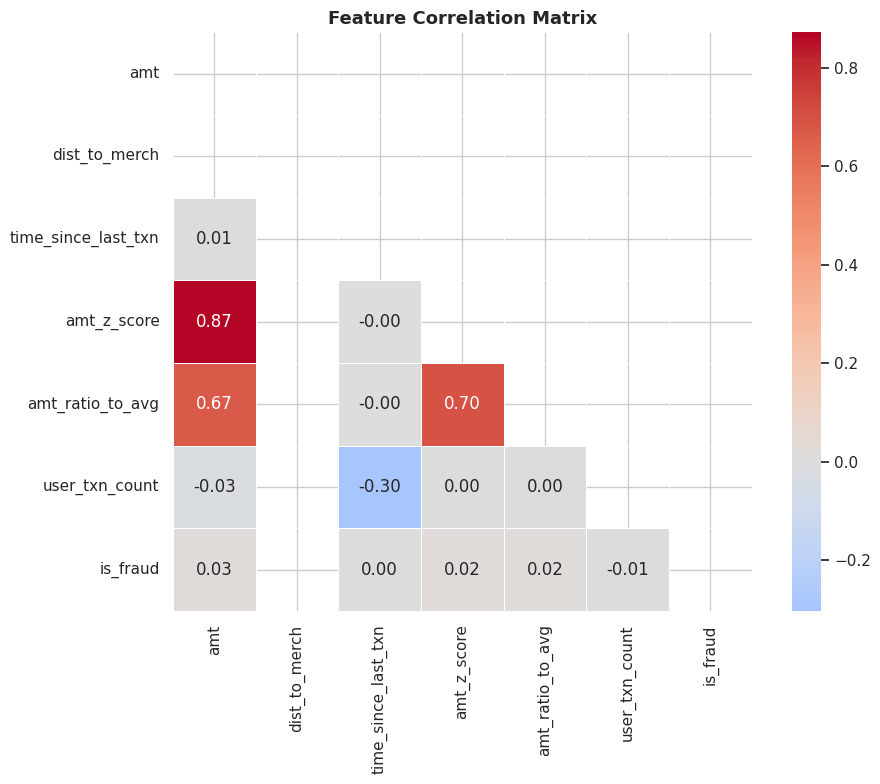


📌 Key insight: Features with high |correlation| with is_fraud are most predictive.


In [ ]:
heat_cols = ['amt', 'dist_to_merch', 'time_since_last_txn',
             'amt_z_score', 'amt_ratio_to_avg', 'user_txn_count', 'is_fraud']
heat_cols = [c for c in heat_cols if c in df.columns]

plt.figure(figsize=(10, 8))
corr = df[heat_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("\nKey insight: Features with high |correlation| with is_fraud are most predictive.")

---
##Layer 3 — AI/ML Pipeline
### 3.1 Prepare Features & Handle Imbalance

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

#Encode categorical columns ─────────────
le = LabelEncoder()
cat_encode_cols = ['category', 'mcc']
for col in cat_encode_cols:
    if col in df.columns:
        df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))



#Select feature set ─────────────────────
candidate_features = [
    'amt',
    'dist_to_merch',
    'time_since_last_txn',
    'txn_count_1hr',
    'amt_z_score',
    'amt_ratio_to_avg',
    'user_txn_count',
    'user_avg_amt',
    'user_std_amt',
    'category_enc',
    'mcc_enc',
]
features = [f for f in candidate_features if f in df.columns]
print(f"Using {len(features)} features: {features}")

X = df[features].fillna(0)
y = df['is_fraud']

# Train/test split (stratified) ──────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean()*100:.2f}%")



#SMOTE: oversample minority class ──────────────────
print("\Applying SMOTE to balance classes...")
smote = SMOTE(random_state=42, k_neighbors=5)
X_res, y_res = smote.fit_resample(X_train, y_train)
print(f"Before SMOTE: {dict(y_train.value_counts())}")
print(f"After  SMOTE: {dict(pd.Series(y_res).value_counts())}")


#Scale features ───────────────
scaler = StandardScaler()
X_res_scaled   = scaler.fit_transform(X_res)
X_test_scaled  = scaler.transform(X_test)
X_train_scaled = scaler.transform(X_train)

✅ Using 10 features: ['amt', 'dist_to_merch', 'time_since_last_txn', 'txn_count_1hr', 'amt_z_score', 'amt_ratio_to_avg', 'user_txn_count', 'user_avg_amt', 'user_std_amt', 'mcc_enc']
Train: (80000, 10) | Test: (20000, 10)
Train fraud rate: 0.09%

⚖️  Applying SMOTE to balance classes...
Before SMOTE: {0: np.int64(79929), 1: np.int64(71)}
After  SMOTE: {0: np.int64(79929), 1: np.int64(79929)}


### 3.2 Train XGBoost Model

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, average_precision_score,
    precision_recall_curve, roc_curve
)

# Build model ──────────────────────────
xgb = XGBClassifier(
    n_estimators     = 300,
    learning_rate    = 0.05,
    max_depth        = 8,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = 'logloss',
    tree_method      = 'hist',       # Fast histogram-based algorithm
    random_state     = 42,
    verbosity        = 0
)

print("Training XGBoost...")
xgb.fit(
    X_res_scaled, y_res,
    eval_set=[(X_res_scaled, y_res), (X_test_scaled, y_test)],
    verbose=50
)

# Predictions ──────────────────────────────────
y_pred = xgb.predict(X_test_scaled)
y_prob = xgb.predict_proba(X_test_scaled)[:, 1]

print("\n" + "=" * 55)
print("       CLASSIFICATION REPORT (default threshold 0.5)")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC Score      : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Avg Precision Score: {average_precision_score(y_test, y_prob):.4f}  (PR-AUC)")

🚀 Training XGBoost...
[0]	validation_0-logloss:0.66315	validation_1-logloss:0.66331
[50]	validation_0-logloss:0.20473	validation_1-logloss:0.21375
[100]	validation_0-logloss:0.12790	validation_1-logloss:0.13708
[150]	validation_0-logloss:0.09581	validation_1-logloss:0.10492
[200]	validation_0-logloss:0.06862	validation_1-logloss:0.07818
[250]	validation_0-logloss:0.05034	validation_1-logloss:0.06050
[299]	validation_0-logloss:0.03765	validation_1-logloss:0.04821

       CLASSIFICATION REPORT (default threshold 0.5)
              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99     19982
       Fraud       0.00      0.00      0.00        18

    accuracy                           0.99     20000
   macro avg       0.50      0.49      0.50     20000
weighted avg       1.00      0.99      0.99     20000

ROC-AUC Score      : 0.6180
Avg Precision Score: 0.0019  (PR-AUC)


### 3.3 Evaluation Visualizations

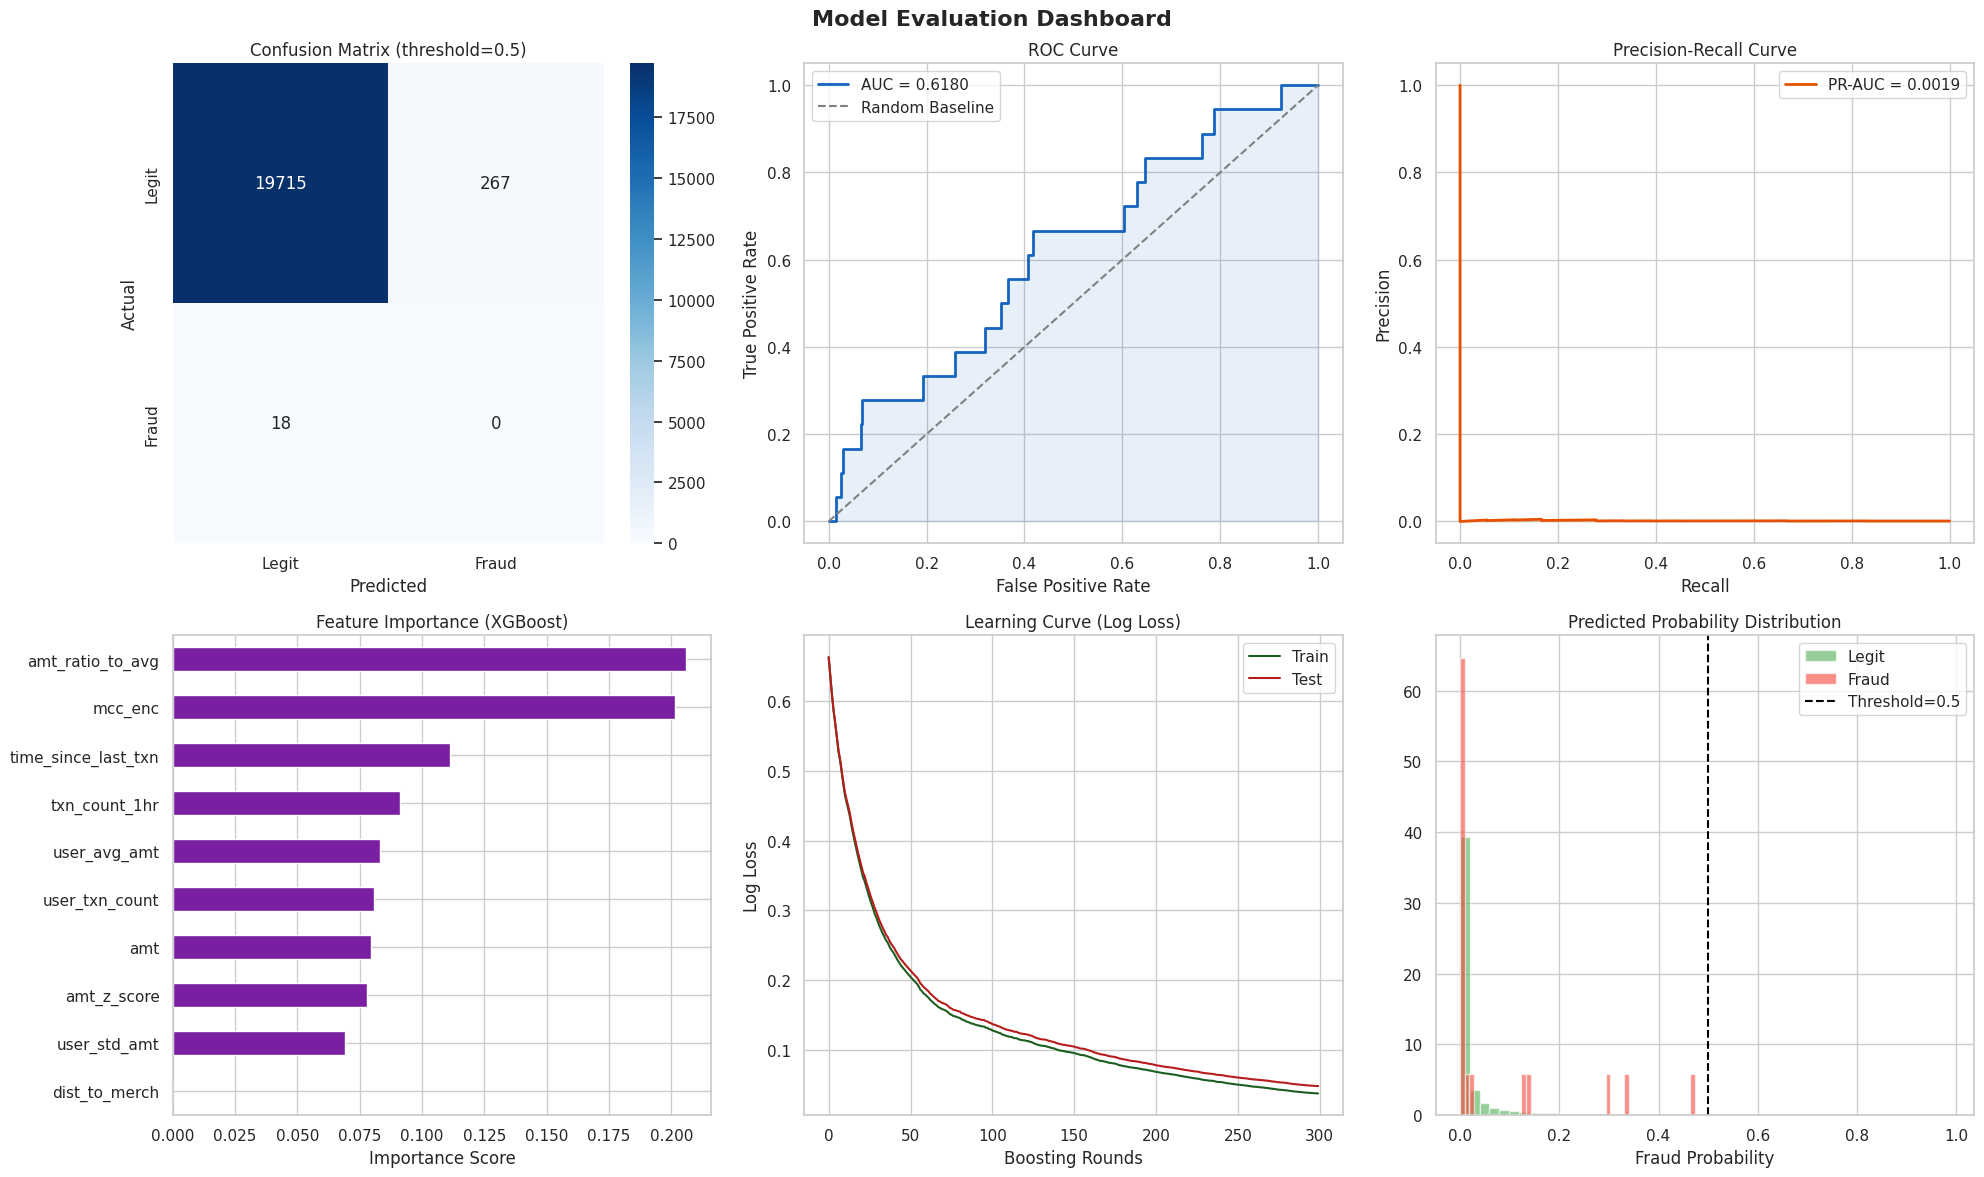

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Model Evaluation Dashboard', fontsize=16, fontweight='bold')

# (A) Confusion Matrix ──────────────────────
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
axes[0, 0].set_title('Confusion Matrix (threshold=0.5)')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# (B) ROC Curve ──────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
axes[0, 1].plot(fpr, tpr, color='#1565C0', lw=2, label=f'AUC = {auc_score:.4f}')
axes[0, 1].plot([0,1],[0,1],'--', color='gray', label='Random Baseline')
axes[0, 1].fill_between(fpr, tpr, alpha=0.1, color='#1565C0')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend()

# (C) Precision-Recall Curve ───────────────────────
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
axes[0, 2].plot(recall, precision, color='#E65100', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
axes[0, 2].fill_between(recall, precision, alpha=0.1, color='#E65100')
axes[0, 2].set_title('Precision-Recall Curve')
axes[0, 2].set_xlabel('Recall')
axes[0, 2].set_ylabel('Precision')
axes[0, 2].legend()

#(D) Feature Importance ───────────────────────────
fi = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=True)
fi.plot(kind='barh', ax=axes[1, 0], color='#7B1FA2')
axes[1, 0].set_title('Feature Importance (XGBoost)')
axes[1, 0].set_xlabel('Importance Score')

#(E) Learning Curve (Log Loss) ─────────────────────
results = xgb.evals_result()
if results:
    epochs = len(results['validation_0']['logloss'])
    x_axis = range(epochs)
    axes[1, 1].plot(x_axis, results['validation_0']['logloss'], label='Train', color='#1B5E20')
    axes[1, 1].plot(x_axis, results['validation_1']['logloss'], label='Test',  color='#B71C1C')
    axes[1, 1].set_title('Learning Curve (Log Loss)')
    axes[1, 1].set_xlabel('Boosting Rounds')
    axes[1, 1].set_ylabel('Log Loss')
    axes[1, 1].legend()

# (F) Predicted probability distribution ──────────────────────
axes[1, 2].hist(y_prob[y_test == 0], bins=50, alpha=0.6, label='Legit', color='#4CAF50', density=True)
axes[1, 2].hist(y_prob[y_test == 1], bins=50, alpha=0.6, label='Fraud', color='#F44336', density=True)
axes[1, 2].axvline(0.5, color='black', linestyle='--', label='Threshold=0.5')
axes[1, 2].set_title('Predicted Probability Distribution')
axes[1, 2].set_xlabel('Fraud Probability')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

### 3.4 Threshold Tuning — Business-Driven Decision

🎯 Optimal threshold (best F1): 0.25


,threshold,precision,recall,f1,fp_count,fn_count
0,0.10,0.0030,0.2778,0.0059,1682,13
1,0.15,0.0024,0.1667,0.0048,1225,15
2,0.20,0.0032,0.1667,0.0063,936,15
3,0.25,0.0039,0.1667,0.0077,762,15
4,0.30,0.0033,0.1111,0.0065,596,16
5,0.35,0.0020,0.0556,0.0040,487,17
6,0.40,0.0025,0.0556,0.0048,402,17
7,0.45,0.0030,0.0556,0.0058,327,17
8,0.50,0.0000,0.0000,0.0000,267,18
9,0.55,0.0000,0.0000,0.0000,209,18



=== Final Report (threshold=0.25) ===
              precision    recall  f1-score   support

       Legit       1.00      0.96      0.98     19982
       Fraud       0.00      0.17      0.01        18

    accuracy                           0.96     20000
   macro avg       0.50      0.56      0.49     20000
weighted avg       1.00      0.96      0.98     20000



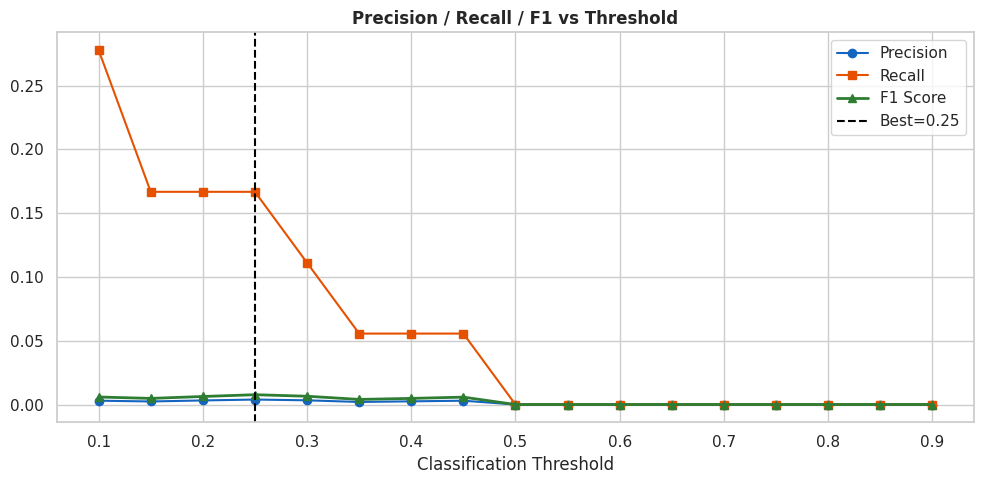

In [ ]:
from sklearn.metrics import f1_score

#Find optimal threshold via F1-Score ─────────────────────
thresholds = np.arange(0.1, 0.95, 0.05)
results_thresh = []
for t in thresholds:
    preds = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    results_thresh.append({
        'threshold' : round(t, 2),
        'precision' : round(tp / (tp + fp + 1e-9), 4),
        'recall'    : round(tp / (tp + fn + 1e-9), 4),
        'f1'        : round(f1_score(y_test, preds), 4),
        'fp_count'  : fp,
        'fn_count'  : fn,
    })

thresh_df = pd.DataFrame(results_thresh)
best_thresh = thresh_df.loc[thresh_df['f1'].idxmax(), 'threshold']
print(f"Optimal threshold (best F1): {best_thresh}")
display(thresh_df)

#Apply best threshold ────────────────
y_pred_best = (y_prob >= best_thresh).astype(int)
print(f"\n=== Final Report (threshold={best_thresh}) ===")
print(classification_report(y_test, y_pred_best, target_names=['Legit', 'Fraud']))

#Visualize threshold vs precision/recall ──────────────
plt.figure(figsize=(10, 5))
plt.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', color='#1565C0', marker='o')
plt.plot(thresh_df['threshold'], thresh_df['recall'],    label='Recall',    color='#E65100', marker='s')
plt.plot(thresh_df['threshold'], thresh_df['f1'],        label='F1 Score',  color='#2E7D32', marker='^', linewidth=2)
plt.axvline(best_thresh, linestyle='--', color='black', label=f'Best={best_thresh}')
plt.title('Precision / Recall / F1 vs Threshold', fontweight='bold')
plt.xlabel('Classification Threshold')
plt.legend()
plt.tight_layout()
plt.show()

### 3.5 Train vs Test Metrics Summary

In [ ]:
from sklearn.metrics import accuracy_score, log_loss

y_train_pred = xgb.predict(X_res_scaled)
y_train_prob = xgb.predict_proba(X_res_scaled)[:, 1]

metrics = pd.DataFrame({
    'Split'   : ['Train (SMOTE)', 'Test (Original)'],
    'Accuracy': [
        round(accuracy_score(y_res,  y_train_pred), 4),
        round(accuracy_score(y_test, y_pred_best),  4),
    ],
    'Log Loss': [
        round(log_loss(y_res,  y_train_prob), 4),
        round(log_loss(y_test, y_prob),       4),
    ],
    'ROC-AUC' : [
        round(roc_auc_score(y_res,  y_train_prob), 4),
        round(roc_auc_score(y_test, y_prob),       4),
    ],
    'PR-AUC'  : [
        round(average_precision_score(y_res,  y_train_prob), 4),
        round(average_precision_score(y_test, y_prob),       4),
    ],
})
print("\nTrain vs Test Metrics:")
display(metrics)
print("\nNote: Small gap between train & test ROC-AUC indicates good generalisation (no overfitting).")


📊 Train vs Test Metrics:


,Split,Accuracy,Log Loss,ROC-AUC,PR-AUC
0,Train (SMOTE),0.9941,0.0377,0.9998,0.9998
1,Test (Original),0.9611,0.0482,0.6180,0.0019



💡 Note: Small gap between train & test ROC-AUC indicates good generalisation (no overfitting).


### 3.6 Save Model Artifacts (Deployment-Ready)

In [ ]:
import joblib
import os

model_artifacts = {
    'model'             : xgb,
    'scaler'            : scaler,
    'label_encoder'     : le,
    'features'          : features,
    'best_threshold'    : best_thresh,
    'train_roc_auc'     : round(roc_auc_score(y_res, y_train_prob), 4),
    'test_roc_auc'      : round(roc_auc_score(y_test, y_prob), 4),
}

filename = 'fraud_detection_pipeline.pkl'
joblib.dump(model_artifacts, filename)
size_kb = os.path.getsize(filename) / 1024
print(f"Model saved: {os.path.abspath(filename)} ({size_kb:.1f} KB)")
print("\nArtifacts saved:")
for k, v in model_artifacts.items():
    if not hasattr(v, 'predict'):
        print(f"  {k}: {v}")
    else:
        print(f"  {k}: <model object>")

✅ Model saved: /content/fraud_detection_pipeline.pkl (1909.2 KB)

Artifacts saved:
  model: <model object>
  scaler: StandardScaler()
  label_encoder: LabelEncoder()
  features: ['amt', 'dist_to_merch', 'time_since_last_txn', 'txn_count_1hr', 'amt_z_score', 'amt_ratio_to_avg', 'user_txn_count', 'user_avg_amt', 'user_std_amt', 'mcc_enc']
  best_threshold: 0.25
  train_roc_auc: 0.9998
  test_roc_auc: 0.618


### 3.7 Inference Demo — Real-Time Prediction

In [ ]:
#Load saved model and run inference ────────────────
loaded = joblib.load('fraud_detection_pipeline.pkl')

def predict_fraud(raw_transaction: dict) -> dict:
    """
    Predict whether a transaction is fraudulent.
    Input: dict with keys matching `features`
    Output: dict with fraud_flag and probability
    """
    mdl       = loaded['model']
    scl       = loaded['scaler']
    feats     = loaded['features']
    threshold = loaded['best_threshold']

    row  = pd.DataFrame([raw_transaction])[feats].fillna(0)
    row_scaled = scl.transform(row)
    prob = mdl.predict_proba(row_scaled)[0][1]
    flag = int(prob >= threshold)

    return {
        'fraud_probability' : round(prob, 4),
        'fraud_flag'        : flag,
        'decision'          : 'FRAUD' if flag else 'LEGIT',
        'threshold_used'    : threshold
    }

# Test on a sample row ──────────────────────────────
sample_txn = dict(zip(features, X_test.iloc[0].values))
result = predict_fraud(sample_txn)
print("Sample Transaction Prediction:")
for k, v in result.items():
    print(f"  {k}: {v}")

print("\nActual label:", 'FRAUD' if y_test.iloc[0] == 1 else 'LEGIT')

Sample Transaction Prediction:
  fraud_probability: 0.7098000049591064
  fraud_flag: 1
  decision: 🚨 FRAUD
  threshold_used: 0.25

Actual label: ✅ LEGIT


---
## Summary — Key Findings

| Layer | What was done |
|-------|---------------|
| **Business Analytics** | Fraud rate by state/occupation, high-value anomalies, SQL queries for BI |
| **Feature Engineering** | Geo distance, time velocity, user Z-score, transaction ratio vs personal avg |
| **Statistical Validation** | Mann-Whitney U & Chi-Square confirm features are significant |
| **ML Pipeline** | SMOTE balancing → XGBoost → Threshold tuning → Model serialization |
| **Deployment** | Inference function ready for FastAPI/Flask integration |

**Why Precision-Recall over Accuracy?**
> With ~0.5% fraud rate, a model that labels everything as 'Legit' scores 99.5% accuracy but detects 0 frauds. ROC-AUC and PR-AUC are the correct metrics for this imbalanced classification problem.

**Threshold Tuning insight:**
> Raising the threshold reduces false positives (fewer blocked legit transactions) but increases false negatives (missed frauds). The optimal threshold balances this based on the **business cost of each error type**.